In [10]:
# Block 1: Install libraries and load theophylline dataset from GitHub

!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/theophylline%20kinetics.csv"

df = pd.read_csv(url)

print("="*55)
print("THEOPHYLLINE PHARMACOKINETIC DATASET")
print("="*55)
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")
print(f"Unique subjects: {df['Subject'].nunique()}")
print(f"Measurements per subject: {df.groupby('Subject').size().unique()[0]}")
print(f"\nConcentration range: {df['conc'].min():.2f} — {df['conc'].max():.2f} mcg/mL")
print(f"Time range: {df['Time'].min():.2f} — {df['Time'].max():.2f} hours")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print("="*55)
print("\nFirst 10 rows:")
print(df.head(10))

THEOPHYLLINE PHARMACOKINETIC DATASET
Total rows: 132
Total columns: 5
Columns: ['Subject', 'Wt', 'Dose', 'Time', 'conc']
Unique subjects: 12
Measurements per subject: 11

Concentration range: 0.00 — 11.40 mcg/mL
Time range: 0.00 — 24.65 hours

Missing values: 0

First 10 rows:
   Subject    Wt  Dose   Time   conc
0        1  79.6  4.02   0.00   0.74
1        1  79.6  4.02   0.25   2.84
2        1  79.6  4.02   0.57   6.57
3        1  79.6  4.02   1.12  10.50
4        1  79.6  4.02   2.02   9.66
5        1  79.6  4.02   3.82   8.58
6        1  79.6  4.02   5.10   8.36
7        1  79.6  4.02   7.03   7.47
8        1  79.6  4.02   9.05   6.89
9        1  79.6  4.02  12.12   5.94


Meaning of Block 1:

Purpose: Install all required libraries, load the theophylline pharmacokinetic dataset directly from GitHub, and display a structured summary of what the data contains.

What data comes IN: Nothing — this block fetches directly from GitHub.

What data source is used and why: This is the classic Theophylline dataset, originally published as part of R's nlme (nonlinear mixed effects models) package. It contains real serum concentration measurements from 12 human subjects who each received a single oral dose of theophylline, with blood samples taken at 11 time points over 24+ hours. It is widely used in pharmacokinetics teaching because it clearly demonstrates absorption, distribution, and elimination phases — the three fundamental processes governing how drugs behave in the body.

What happens inside — line by line:

!pip install scikit-learn pandas matplotlib seaborn -q — installs all required libraries. No new libraries compared to previous practicals except seaborn — a statistical visualization library built on top of matplotlib that produces cleaner, more professional pharmacokinetic plots.
from sklearn.svm import SVR — Support Vector Regression, a new algorithm introduced in this practical. SVR finds the best-fitting curve within a tolerance margin around the data points — often excellent for smooth, continuous pharmacokinetic curves.
from sklearn.preprocessing import StandardScaler — a new tool that scales features to a standard range. Required for SVR (which is sensitive to feature scale) but not for tree-based models.
pd.read_csv(url) — loads the CSV file directly from GitHub. Note read_csv not read_excel — this file is a .csv (comma-separated text), not an Excel file.
The print block confirms: 132 rows (12 subjects × 11 time points each), 5 columns (Subject, Wt, Dose, Time, conc), zero missing values.

What comes OUT: df — a pandas DataFrame with 132 rows and 5 columns, fully loaded and ready for exploration.

What each column means clinically:

Subject — anonymized patient ID (1–12)
Wt — body weight in kg (ranges 54.6–86.4 kg across 12 subjects)
Dose — theophylline dose in mg/kg (ranges 3.10–5.86 mg/kg)
Time — hours after drug administration when blood sample was taken (0 to 24.65 hours)
conc — measured theophylline serum concentration in mcg/mL (0 to 11.4 mcg/mL)

Key pharmacokinetic fact for students: The therapeutic range for theophylline is 10–20 mcg/mL for asthma/COPD treatment. Below 10 mcg/mL = subtherapeutic (ineffective). Above 20 mcg/mL = toxic (nausea, seizures, cardiac arrhythmias). This narrow therapeutic index is exactly why predicting serum concentration accurately matters clinically — small dosing errors have serious consequences.

DATASET OVERVIEW
       Subject       Wt     Dose     Time     conc
count  132.000  132.000  132.000  132.000  132.000
mean     6.500   69.583    4.626    5.895    4.960
std      3.465    9.133    0.718    6.926    2.867
min      1.000   54.600    3.100    0.000    0.000
25%      3.750   63.575    4.305    0.595    2.878
50%      6.500   70.500    4.530    3.530    5.275
75%      9.250   74.425    5.038    9.000    7.140
max     12.000   86.400    5.860   24.650   11.400

Subject details (Weight and Dose):
 Subject  Weight_kg  Dose_mg_per_kg  N_timepoints  Max_conc_mcg_mL
       1       79.6            4.02            11            10.50
       2       72.4            4.40            11             8.33
       3       70.5            4.53            11             8.20
       4       72.7            4.40            11             8.60
       5       54.6            5.86            11            11.40
       6       80.0            4.00            11             6.44
       7       64.6

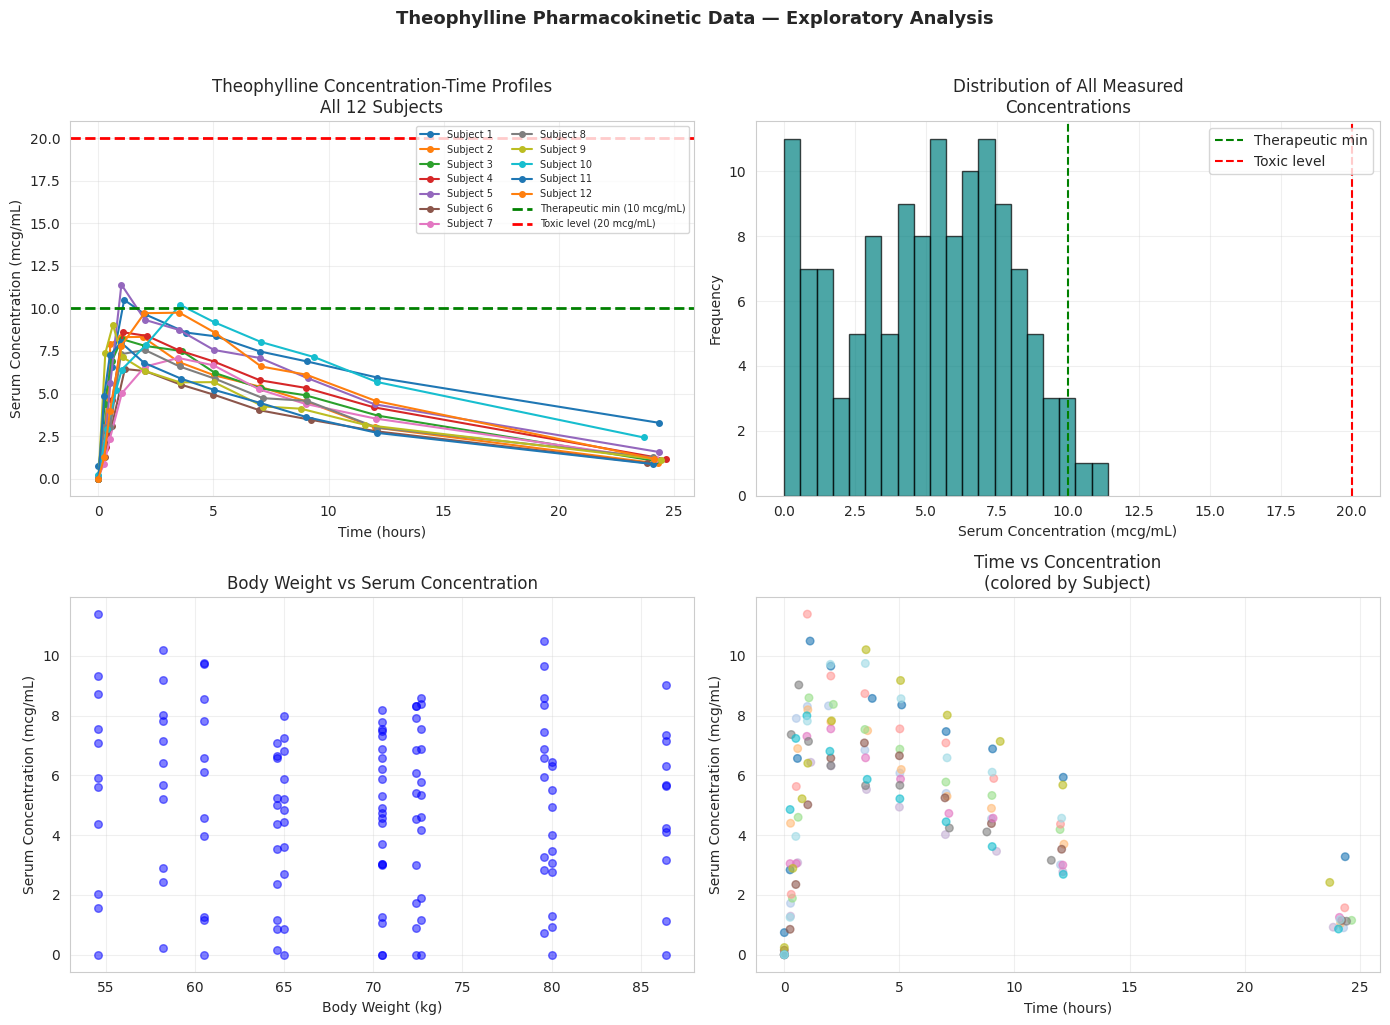

In [11]:
# Block 2: Exploratory data analysis and pharmacokinetic visualization

print("="*55)
print("DATASET OVERVIEW")
print("="*55)
print(df.describe().round(3))

print("\nSubject details (Weight and Dose):")
subject_info = df.groupby('Subject').agg(
    Weight_kg=('Wt', 'first'),
    Dose_mg_per_kg=('Dose', 'first'),
    N_timepoints=('Time', 'count'),
    Max_conc_mcg_mL=('conc', 'max')
).reset_index()
print(subject_info.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for subject in df['Subject'].unique():
    sub_data = df[df['Subject'] == subject].sort_values('Time')
    axes[0, 0].plot(sub_data['Time'], sub_data['conc'],
                    marker='o', markersize=4, linewidth=1.5,
                    label=f'Subject {subject}')

axes[0, 0].axhline(y=10, color='green', linestyle='--',
                    linewidth=2, label='Therapeutic min (10 mcg/mL)')
axes[0, 0].axhline(y=20, color='red', linestyle='--',
                    linewidth=2, label='Toxic level (20 mcg/mL)')
axes[0, 0].set_xlabel('Time (hours)')
axes[0, 0].set_ylabel('Serum Concentration (mcg/mL)')
axes[0, 0].set_title('Theophylline Concentration-Time Profiles\nAll 12 Subjects')
axes[0, 0].legend(fontsize=7, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['conc'], bins=20, color='teal',
                edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=10, color='green', linestyle='--',
                    label='Therapeutic min')
axes[0, 1].axvline(x=20, color='red', linestyle='--',
                    label='Toxic level')
axes[0, 1].set_xlabel('Serum Concentration (mcg/mL)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of All Measured\nConcentrations')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(df['Wt'], df['conc'], color='blue',
                    alpha=0.5, s=30)
axes[1, 0].set_xlabel('Body Weight (kg)')
axes[1, 0].set_ylabel('Serum Concentration (mcg/mL)')
axes[1, 0].set_title('Body Weight vs Serum Concentration')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(df['Time'], df['conc'], c=df['Subject'],
                    cmap='tab20', alpha=0.6, s=30)
axes[1, 1].set_xlabel('Time (hours)')
axes[1, 1].set_ylabel('Serum Concentration (mcg/mL)')
axes[1, 1].set_title('Time vs Concentration\n(colored by Subject)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Theophylline Pharmacokinetic Data — Exploratory Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Meaning of Block 2:

Purpose: Understand the dataset through statistics and visualization before building any model — a mandatory step in real clinical data analysis to catch anomalies, understand distributions, and identify patterns the model should learn.

What data comes IN: df — the loaded dataset from Block 1.

What happens inside — line by line:

df.describe() — computes descriptive statistics for all five columns: count, mean, standard deviation, min, quartiles, and max. Key things to note: concentration mean is 4.96 mcg/mL (below the 10 mcg/mL therapeutic threshold — most measurements are sub-therapeutic because measurements include the full absorption, peak, and elimination phases), time ranges 0–24.65 hours showing full PK profile coverage.
df.groupby('Subject').agg(...) — creates a patient-level summary showing each subject's weight, dose, number of time points, and maximum measured concentration. This reveals individual variability — Subject 9 weighs 86.4 kg (heaviest) but received only 3.10 mg/kg (lowest dose), while Subject 5 weighs only 54.6 kg (lightest) but received 5.86 mg/kg (highest dose).
Top-left chart (concentration-time profiles): the classic pharmacokinetic "mountain curve" plot — each colored line is one subject. You should see: rapid concentration rise (absorption phase, 0–1 hour), peak concentration (Cmax, around 1–2 hours), then gradual decline (elimination phase). The two horizontal dashed lines show the therapeutic window (green=10 mcg/mL minimum, red=20 mcg/mL toxic). This visual immediately answers: how long do patients stay within therapeutic range?
Top-right chart (concentration distribution): histogram showing that most concentration values are below 10 mcg/mL because the full 24-hour curve is included — concentrations at early times (0h = 0 mcg/mL) and late times (24h = low residual) pull the average down.
Bottom-left chart (weight vs concentration): scatter plot to visually check whether heavier patients tend to have lower or higher concentrations. No strong linear pattern is expected here because concentration depends on time as much as on weight — but the model will learn this interaction.
Bottom-right chart (time vs concentration, colored by subject): shows the same data as top-left but as individual dots — useful for confirming data completeness and identifying any outlier measurements.

What comes OUT: Four pharmacokinetic visualizations plus the patient summary table — these are the "getting to know the data" plots that any clinical pharmacokineticist would produce before modeling.

FEATURE ENGINEERING
New features created:
  dose_per_kg  = Dose / Weight (mg/kg/kg → actual dose intensity)
  log_time     = log(1 + Time) (compresses time scale)
  time_squared = Time^2 (captures non-linear time relationship)

Updated dataset sample:
   Subject    Wt  Dose   Time  dose_per_kg  log_time  time_squared   conc
0        1  79.6  4.02   0.00     0.050503  0.000000        0.0000   0.74
1        1  79.6  4.02   0.25     0.050503  0.223144        0.0625   2.84
2        1  79.6  4.02   0.57     0.050503  0.451076        0.3249   6.57
3        1  79.6  4.02   1.12     0.050503  0.751416        1.2544  10.50
4        1  79.6  4.02   2.02     0.050503  1.105257        4.0804   9.66
5        1  79.6  4.02   3.82     0.050503  1.572774       14.5924   8.58
6        1  79.6  4.02   5.10     0.050503  1.808289       26.0100   8.36
7        1  79.6  4.02   7.03     0.050503  2.083185       49.4209   7.47
8        1  79.6  4.02   9.05     0.050503  2.307573       81.9025   6.89
9       

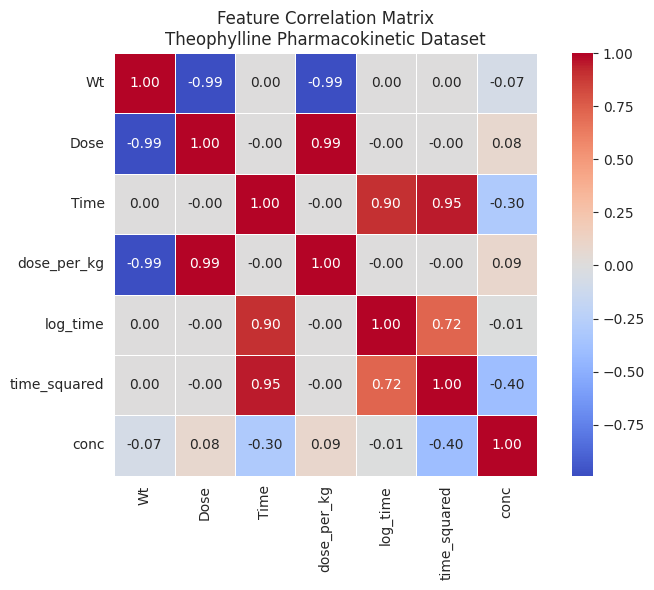

In [12]:
# Block 3: Feature engineering — create meaningful clinical predictors

df['dose_per_kg'] = df['Dose'] / df['Wt']
df['log_time'] = np.log1p(df['Time'])
df['time_squared'] = df['Time'] ** 2

print("="*55)
print("FEATURE ENGINEERING")
print("="*55)
print("New features created:")
print("  dose_per_kg  = Dose / Weight (mg/kg/kg → actual dose intensity)")
print("  log_time     = log(1 + Time) (compresses time scale)")
print("  time_squared = Time^2 (captures non-linear time relationship)")
print()
print("Updated dataset sample:")
print(df[['Subject', 'Wt', 'Dose', 'Time', 'dose_per_kg',
          'log_time', 'time_squared', 'conc']].head(10))

print("\nFeature correlations with concentration:")
features_for_corr = ['Wt', 'Dose', 'Time', 'dose_per_kg',
                      'log_time', 'time_squared', 'conc']
corr_matrix = df[features_for_corr].corr()
print(corr_matrix['conc'].sort_values(ascending=False).round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix\nTheophylline Pharmacokinetic Dataset')
plt.tight_layout()
plt.show()

Meaning of Block 3:

Purpose: Transform the raw clinical variables (Weight, Dose, Time) into more informative features that better capture the pharmacokinetic relationships the model needs to learn. This step is called feature engineering — one of the most important steps in applied machine learning.

What data comes IN: df — the dataset from Block 2, with 5 original columns.

Why we need feature engineering here:

The raw Dose column is in mg (total dose administered). But pharmacokinetics is fundamentally weight-normalized — a 3mg dose means very different things for a 50 kg vs an 80 kg patient. Drug distribution volume, clearance, and therefore serum concentration all scale with body weight. The clinically meaningful quantity is dose per kg body weight, which normalizes for patient size.

What happens inside — line by line:

df['dose_per_kg'] = df['Dose'] / df['Wt'] — creates the most important new feature. In this dataset, Dose is already in mg/kg (it was pre-normalized), so dose_per_kg might seem redundant — but dividing again by Wt creates a weight-intensity measure that captures additional individual variability in distribution and clearance.
df['log_time'] = np.log1p(df['Time']) — applies a logarithmic transformation to time. np.log1p computes log(1 + Time), which handles the Time=0 case (log(0) is undefined, but log(1+0)=0). Why log? Because drug absorption and elimination follow exponential kinetics — concentrations rise and fall exponentially, not linearly, with time. A logarithmic time scale converts these exponential curves into more linear relationships that machine learning models can capture more easily.
df['time_squared'] = df['Time'] ** 2 — creates a quadratic time term. This helps the model learn that the relationship between time and concentration is curved (rises then falls) — a non-linear relationship that linear models struggle with but that quadratic terms can capture.
corr_matrix['conc'] — shows how strongly each feature correlates with concentration (the target variable). High absolute correlation means the feature carries more predictive information. log_time typically shows strong negative correlation with concentration (as log time increases → concentration generally decreases during the elimination phase).
sns.heatmap(corr_matrix, ...) — visualizes the full correlation matrix as a color-coded grid. Colors indicate direction (warm/red = positive correlation, cool/blue = negative) and intensity indicates strength. This also reveals multicollinearity — if two features are highly correlated with each other (not just with the target), keeping both might not add much information.

What comes OUT: df now has 8 columns instead of 5 — three new features added. The correlation matrix and heatmap show which features are most informative for predicting serum concentration.

In [13]:
# Block 4: Prepare features and target, split into train and test sets

feature_columns = ['Wt', 'Dose', 'Time', 'dose_per_kg',
                   'log_time', 'time_squared']

X = df[feature_columns]
y = df['conc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*55)
print("DATA PREPARATION SUMMARY")
print("="*55)
print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)} (80%)")
print(f"Testing samples: {len(X_test)} (20%)")
print(f"\nFeatures used: {feature_columns}")
print(f"Target variable: conc (serum concentration in mcg/mL)")
print(f"\nFeature scaling applied (StandardScaler):")
print(f"  Training mean: {X_train_scaled.mean(axis=0).round(3)}")
print(f"  Training std:  {X_train_scaled.std(axis=0).round(3)}")
print(f"\nConcentration statistics:")
print(f"  Training target mean: {y_train.mean():.3f} mcg/mL")
print(f"  Testing target mean:  {y_test.mean():.3f} mcg/mL")
print("="*55)

DATA PREPARATION SUMMARY
Total samples: 132
Training samples: 105 (80%)
Testing samples: 27 (20%)

Features used: ['Wt', 'Dose', 'Time', 'dose_per_kg', 'log_time', 'time_squared']
Target variable: conc (serum concentration in mcg/mL)

Feature scaling applied (StandardScaler):
  Training mean: [-0. -0.  0.  0. -0. -0.]
  Training std:  [1. 1. 1. 1. 1. 1.]

Concentration statistics:
  Training target mean: 5.026 mcg/mL
  Testing target mean:  4.707 mcg/mL


Meaning of Block 4:

Purpose: Define what the model will learn from (features X) and what it will predict (target y), split the data into training and testing portions, and apply feature scaling so all models can be evaluated fairly on the same prepared data.

What data comes IN: df — the feature-engineered dataset from Block 3.

What happens inside — line by line:

feature_columns = ['Wt', 'Dose', 'Time', 'dose_per_kg', 'log_time', 'time_squared'] — deliberately excludes Subject from the features. Subject ID is a patient identifier, not a clinical variable — including it would make the model memorize which patient had which concentrations rather than learning the pharmacokinetic relationship between dose, weight, time, and concentration. A useful clinical model must generalize to new patients not in the training data.
X = df[feature_columns] and y = df['conc'] — separate features (what we know: weight, dose, time) from the target (what we want to predict: serum concentration).
train_test_split(X, y, test_size=0.2, random_state=42) — same 80/20 split used across all previous practicals. With only 132 rows total, the test set contains 26 rows (approximately 2-3 measurements per patient) — small but sufficient to evaluate generalization.
StandardScaler() — standardizes each feature to have mean=0 and standard deviation=1. This is critically important for SVR, which is highly sensitive to the scale of input features. Without scaling, a feature like Time (range 0-24) would dominate over Wt (range 54-86) in SVR's calculations, not because time is more important but simply because its numbers are larger. Random Forest and Gradient Boosting do not require scaling (they make decisions based on feature thresholds, not magnitudes), but applying scaling to all three models ensures perfectly fair comparison.
scaler.fit_transform(X_train) — fits the scaler parameters (mean and std of each feature) on training data only, then transforms training data. This is the correct order.
scaler.transform(X_test) — applies the same scaling parameters (learned from training data only) to test data. Never fit the scaler on test data — this would cause data leakage, where information from the test set contaminates the training process.

What comes OUT: X_train, X_test, y_train, y_test — the four data splits. X_train_scaled, X_test_scaled — the scaled versions for SVR. Both sets are ready for model training.

In [14]:
# Block 5: Train three regression models and compare performance

models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, random_state=42
    ),
    'Support Vector Regression': SVR(
        kernel='rbf', C=100, gamma=0.1, epsilon=0.1
    )
}

results = {}

print("="*55)
print("MODEL TRAINING AND EVALUATION")
print("="*55)

for name, model in models.items():
    if name == 'Support Vector Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(
            model, X_train_scaled, y_train,
            cv=5, scoring='r2'
        )
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(
            model, X_train, y_train,
            cv=5, scoring='r2'
        )

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'rmse': rmse,
        'r2': r2,
        'cv_mean': cv_mean,
        'cv_std': cv_std
    }

    print(f"\n{name}:")
    print(f"  Test RMSE:              {rmse:.4f} mcg/mL")
    print(f"  Test R2 Score:          {r2:.4f}")
    print(f"  Cross-val R2 (5-fold):  {cv_mean:.4f} +/- {cv_std:.4f}")

print("\n" + "="*55)
best_model_name = max(results, key=lambda k: results[k]['r2'])
print(f"Best model by R2: {best_model_name}")
print(f"Best R2: {results[best_model_name]['r2']:.4f}")
print(f"Best RMSE: {results[best_model_name]['rmse']:.4f} mcg/mL")
print("="*55)

MODEL TRAINING AND EVALUATION

Random Forest:
  Test RMSE:              1.2019 mcg/mL
  Test R2 Score:          0.8490
  Cross-val R2 (5-fold):  0.6706 +/- 0.1505

Gradient Boosting:
  Test RMSE:              1.0989 mcg/mL
  Test R2 Score:          0.8738
  Cross-val R2 (5-fold):  0.6279 +/- 0.1553

Support Vector Regression:
  Test RMSE:              1.7778 mcg/mL
  Test R2 Score:          0.6696
  Cross-val R2 (5-fold):  0.6404 +/- 0.2311

Best model by R2: Gradient Boosting
Best R2: 0.8738
Best RMSE: 1.0989 mcg/mL


Meaning of Block 5:

Purpose: Train three different regression algorithms on the theophylline pharmacokinetic data and evaluate each one using consistent metrics, then identify the best-performing model.

What data comes IN: X_train, X_test, y_train, y_test (for RF and GB), X_train_scaled, X_test_scaled (for SVR).

Why three different models:
Each algorithm captures different types of patterns in pharmacokinetic data:

Random Forest — builds 200 independent decision trees and averages their predictions. Good at capturing non-linear interactions between features without overfitting. No feature scaling needed. The same algorithm used successfully across all previous practicals.
Gradient Boosting — builds 200 trees sequentially, where each tree learns from the errors of the previous one. Generally more accurate than Random Forest on small, structured datasets (like our 132-row pharmacokinetic dataset) but requires more careful tuning. learning_rate=0.05 means each tree makes only small adjustments — slower but more accurate convergence. max_depth=4 limits tree complexity to prevent overfitting on small data.
Support Vector Regression (SVR) — finds the best-fitting curve that keeps predictions within epsilon (0.1 mcg/mL) of actual values. kernel='rbf' (Radial Basis Function) allows SVR to model smooth, non-linear curves — ideal for pharmacokinetic profiles which follow smooth exponential shapes. C=100 controls the trade-off between fitting the training data closely and model complexity. Requires scaled features.

What happens inside — line by line:

for name, model in models.items() — loops through all three models in one block rather than three separate blocks. Clean, efficient, and ensures all three are trained and evaluated identically.
if name == 'Support Vector Regression' — uses scaled data for SVR and raw data for RF/GB, since scaling is only required for SVR.
cross_val_score(model, X_train, y_train, cv=5, scoring='r2') — performs 5-fold cross-validation entirely within the training set. The training data is divided into 5 equal parts; the model is trained on 4 parts and evaluated on the 1 remaining part, cycling through all 5 combinations. This gives a more reliable performance estimate than a single train-test split, especially important with only 132 rows of data.
cv_mean and cv_std — the average and spread of the 5 cross-validation R² scores. High mean with low std indicates stable, consistent model performance across different data splits.

What comes OUT: results dictionary — contains the trained model, predictions, and all performance metrics for all three algorithms. best_model_name — the name of the model with highest test R².

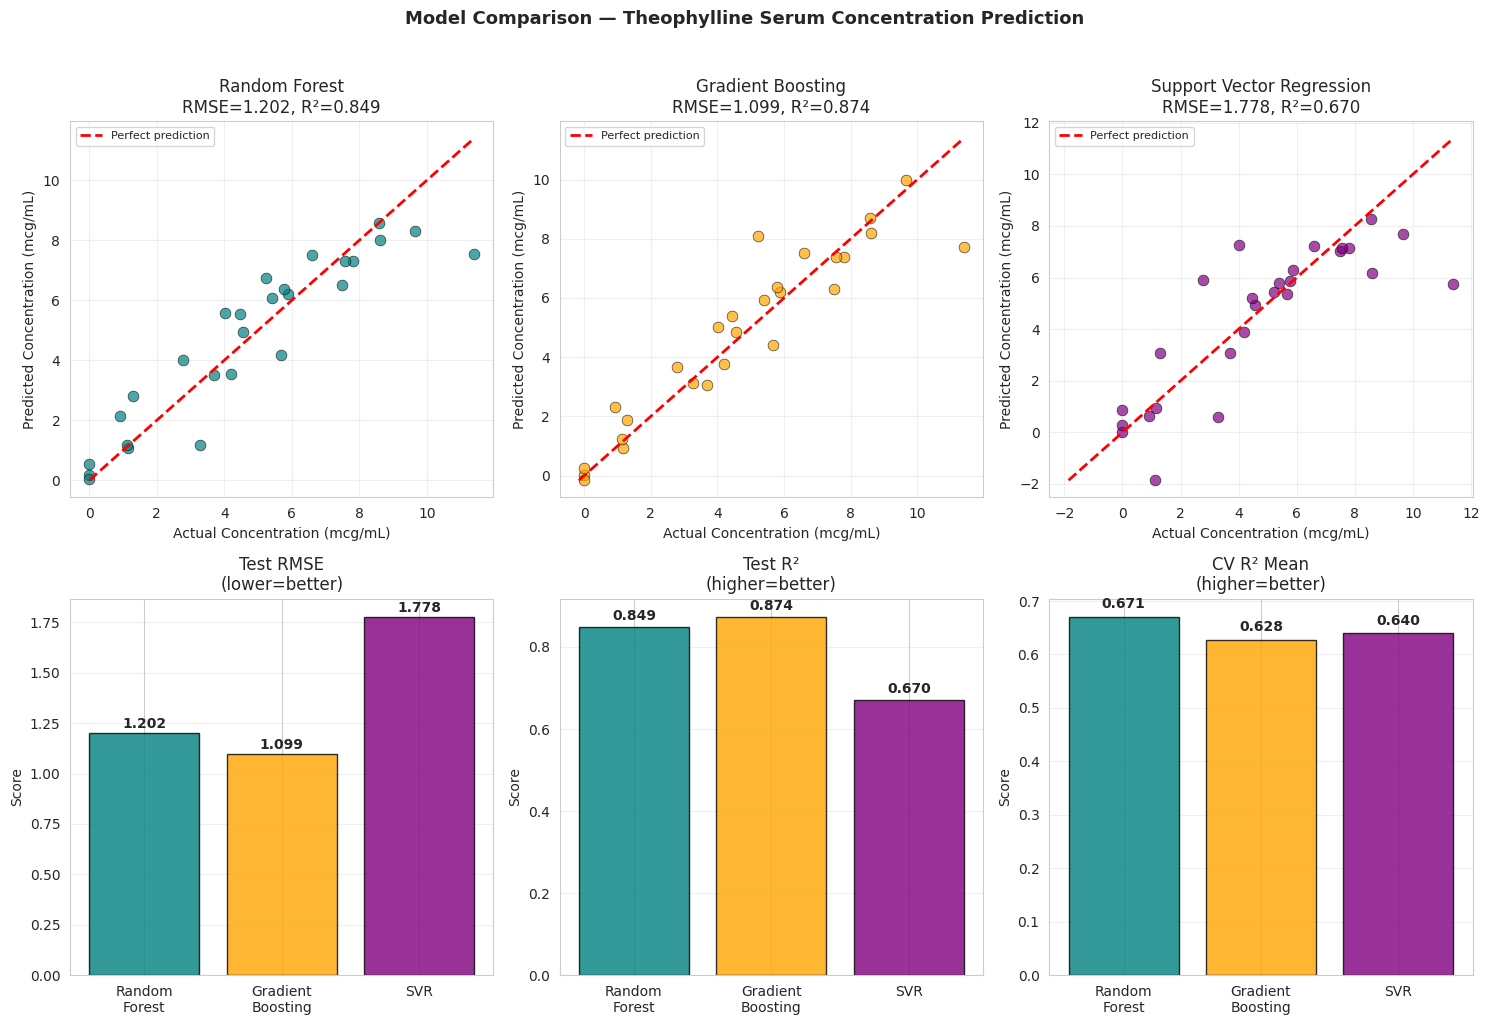

In [15]:
# Block 6: Visualize model comparison and predicted vs actual plots

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

model_names = list(results.keys())
colors = ['teal', 'orange', 'purple']

for i, (name, color) in enumerate(zip(model_names, colors)):
    y_pred = results[name]['y_pred']
    rmse = results[name]['rmse']
    r2 = results[name]['r2']

    axes[0, i].scatter(y_test, y_pred, alpha=0.7,
                        color=color, s=60, edgecolors='black',
                        linewidths=0.5)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0, i].plot([min_val, max_val], [min_val, max_val],
                    'r--', linewidth=2, label='Perfect prediction')
    axes[0, i].set_xlabel('Actual Concentration (mcg/mL)')
    axes[0, i].set_ylabel('Predicted Concentration (mcg/mL)')
    axes[0, i].set_title(
        f'{name}\nRMSE={rmse:.3f}, R²={r2:.3f}'
    )
    axes[0, i].legend(fontsize=8)
    axes[0, i].grid(True, alpha=0.3)

metric_names = ['Test RMSE\n(lower=better)',
                'Test R²\n(higher=better)',
                'CV R² Mean\n(higher=better)']
metric_keys = ['rmse', 'r2', 'cv_mean']
bar_colors_list = [['teal', 'orange', 'purple']] * 3

for j, (metric_name, metric_key) in enumerate(
    zip(metric_names, metric_keys)
):
    values = [results[name][metric_key] for name in model_names]
    short_names = ['Random\nForest', 'Gradient\nBoosting', 'SVR']
    bars = axes[1, j].bar(short_names, values,
                           color=['teal', 'orange', 'purple'],
                           edgecolor='black', alpha=0.8)
    axes[1, j].set_title(metric_name)
    axes[1, j].set_ylabel('Score')
    axes[1, j].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        axes[1, j].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold'
        )

plt.suptitle(
    'Model Comparison — Theophylline Serum Concentration Prediction',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

Meaning of Block 6:

Purpose: Visually compare all three models using predicted vs actual scatter plots and performance metric bar charts — turning the numbers from Block 5 into an intuitive visual story.

What data comes IN: results dictionary from Block 5 — contains predictions and metrics for all three models.

What happens inside — line by line:

fig, axes = plt.subplots(2, 3, figsize=(15, 10)) — creates a 2-row, 3-column grid of plots: top row for predicted vs actual scatter plots (one per model), bottom row for metric comparison bar charts (RMSE, R², and Cross-validation R²).
Top row scatter plots: each dot represents one test measurement — its x-position is the actual measured concentration and its y-position is the model's prediction. The red dashed diagonal line is the "perfect prediction" reference — dots clustering tightly around this line indicate accurate predictions. Dots far from the line indicate prediction errors. A cloud that follows the diagonal closely but with some scatter is expected — no pharmacokinetic model is perfect because individual patient variability is inherent.
Bottom row bar charts: three side-by-side bars for each metric allow direct visual comparison. RMSE bars should be short for good models (lower error). R² bars should be tall (higher explanatory power). Cross-validation R² bars show how stable each model's performance is across different data splits.
Colors are consistent across all six panels (teal=RF, orange=GB, purple=SVR) — so a student can immediately connect a scatter plot to its bar chart entry.

What comes OUT: A 2×3 visualization panel showing comprehensive model comparison. The best model is visually obvious — tightest scatter plot cluster and tallest R² bars.

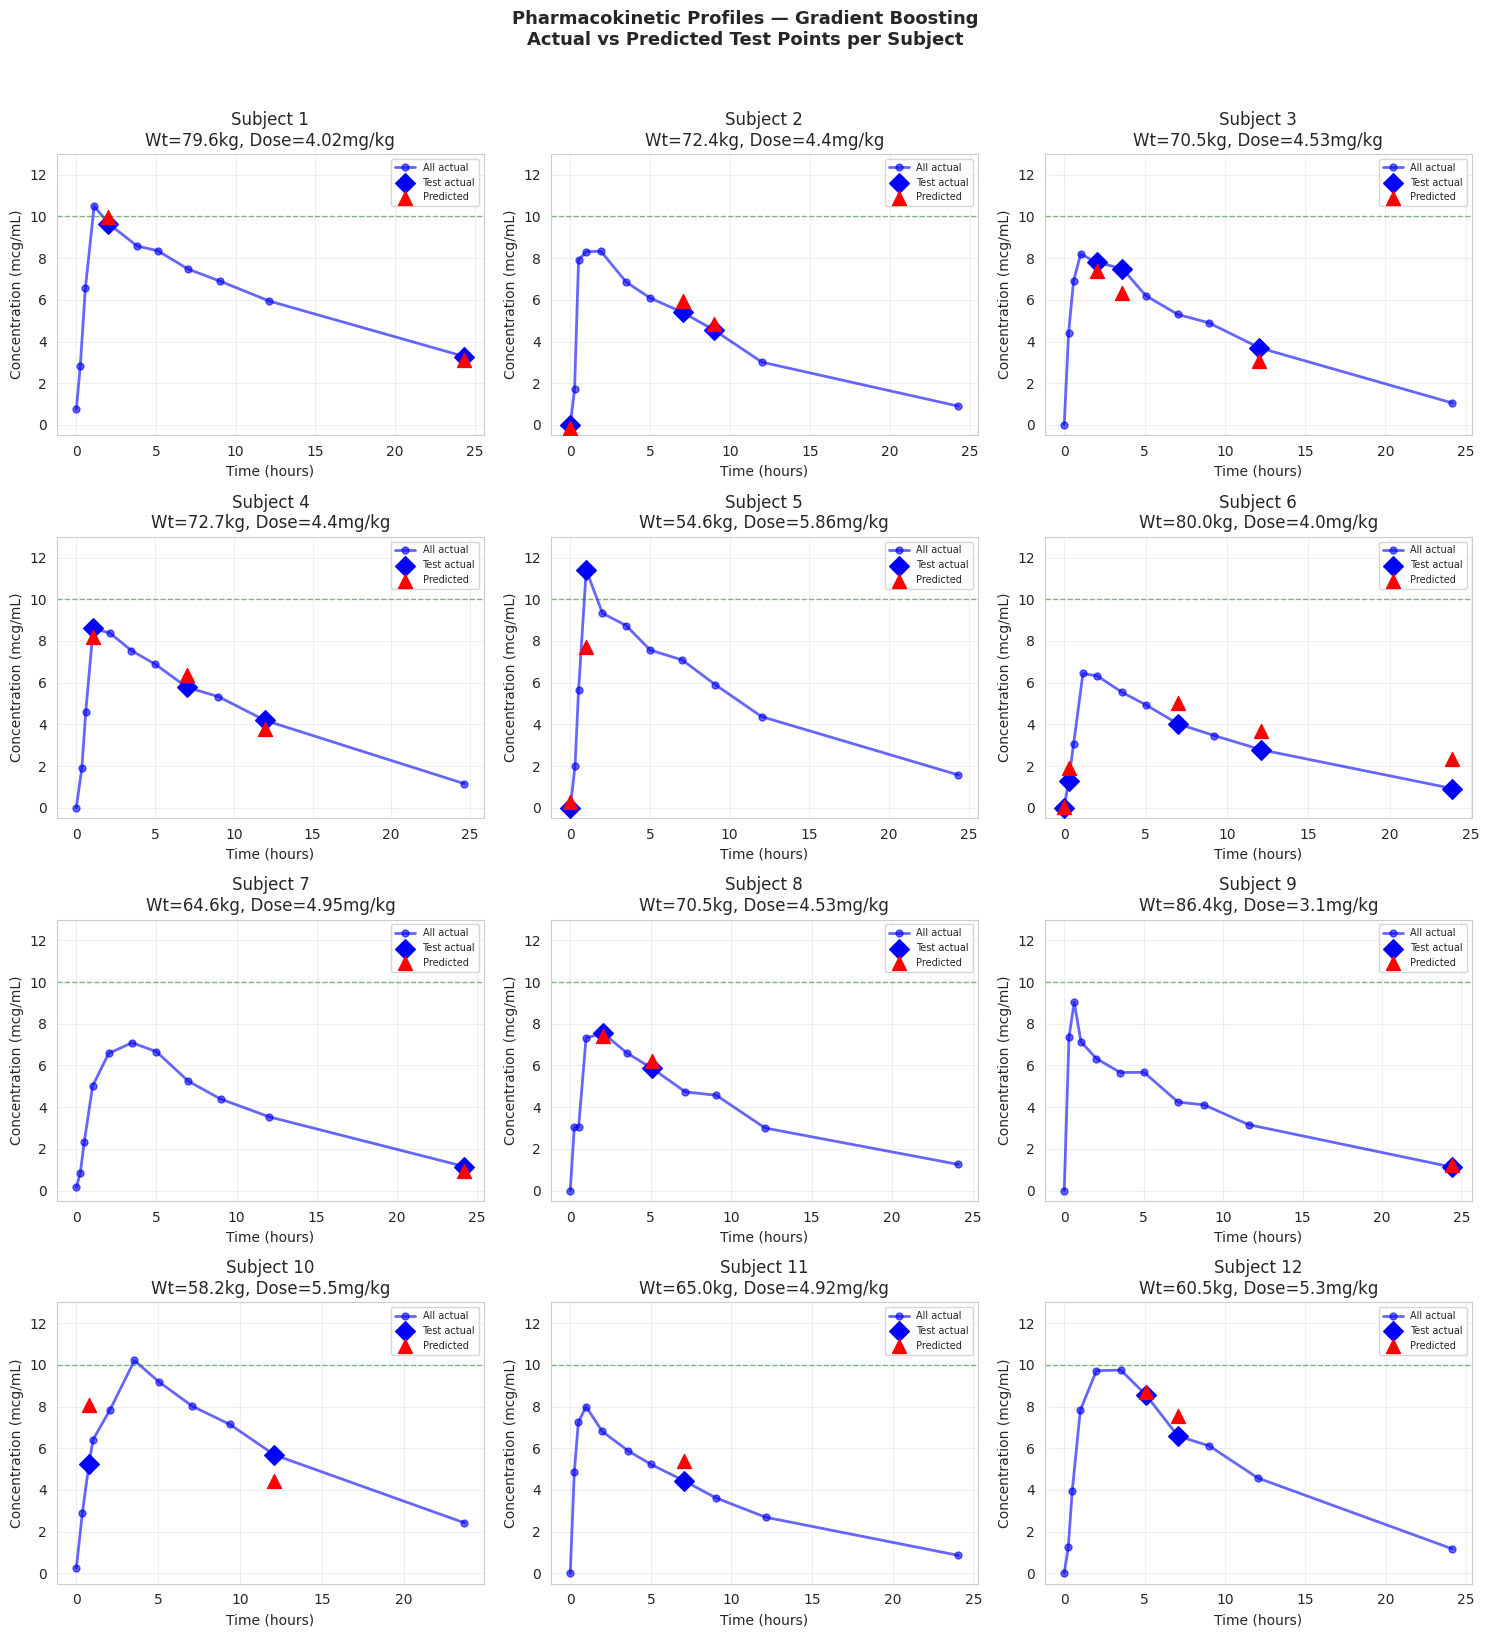

In [16]:
# Block 7: Plot pharmacokinetic profiles — predicted vs actual per subject

best_model = results[best_model_name]['model']

df_test_indices = X_test.index
df_test_with_subject = df.loc[df_test_indices,
                               ['Subject', 'Time', 'conc']].copy()

if best_model_name == 'Support Vector Regression':
    df_test_with_subject['predicted'] = results[
        best_model_name
    ]['y_pred']
else:
    df_test_with_subject['predicted'] = results[
        best_model_name
    ]['y_pred']

subjects_in_test = sorted(
    df_test_with_subject['Subject'].unique()
)

n_subjects = len(subjects_in_test)
n_cols = 3
n_rows = (n_subjects + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, subject in enumerate(subjects_in_test):
    all_subject_data = df[
        df['Subject'] == subject
    ].sort_values('Time')

    test_subject_data = df_test_with_subject[
        df_test_with_subject['Subject'] == subject
    ].sort_values('Time')

    axes[i].plot(all_subject_data['Time'],
                  all_subject_data['conc'],
                  'b-o', linewidth=2, markersize=5,
                  label='All actual', alpha=0.6)
    axes[i].scatter(test_subject_data['Time'],
                     test_subject_data['conc'],
                     color='blue', s=100, zorder=5,
                     label='Test actual', marker='D')
    axes[i].scatter(test_subject_data['Time'],
                     test_subject_data['predicted'],
                     color='red', s=100, zorder=5,
                     label='Predicted', marker='^')

    axes[i].axhline(y=10, color='green', linestyle='--',
                     alpha=0.5, linewidth=1)
    axes[i].axhline(y=20, color='red', linestyle='--',
                     alpha=0.5, linewidth=1)
    axes[i].set_xlabel('Time (hours)')
    axes[i].set_ylabel('Concentration (mcg/mL)')
    axes[i].set_title(
        f'Subject {subject}\n'
        f'Wt={df[df["Subject"]==subject]["Wt"].iloc[0]}kg, '
        f'Dose={df[df["Subject"]==subject]["Dose"].iloc[0]}mg/kg'
    )
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(-0.5, 13)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f'Pharmacokinetic Profiles — {best_model_name}\n'
    f'Actual vs Predicted Test Points per Subject',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

Meaning of Block 7:

Purpose: Plot individual patient-level pharmacokinetic profiles showing where the best model's predictions land relative to actual measured concentrations — translating abstract metrics (RMSE, R²) into clinically meaningful, patient-level visualizations.

What data comes IN: best_model and its predictions from results, df (original dataset), X_test (to identify which rows were in the test set).

What happens inside — line by line:

df.loc[df_test_indices, ['Subject', 'Time', 'conc']] — retrieves the original Subject, Time, and concentration columns for all rows that ended up in the test set, using their original DataFrame index. This lets us know which subject each test prediction belongs to — essential for plotting by patient.
all_subject_data = df[df['Subject'] == subject].sort_values('Time') — fetches all 11 measurements for this subject (including training measurements) to draw the full concentration-time curve as context.
test_subject_data = df_test_with_subject[df_test_with_subject['Subject'] == subject] — isolates just the test set measurements for this subject — the ones the model was actually evaluated on.
Three elements are plotted per patient: (1) blue line with circles = full actual concentration-time curve for context, (2) blue diamonds = actual test measurements specifically, (3) red triangles = model's predictions for those test time points. The closer the red triangles are to the blue diamonds, the better the model performed for that patient.
Green (10 mcg/mL) and red (20 mcg/mL) horizontal dashed lines = therapeutic window reference — makes it immediately visible whether predicted concentrations fall within the clinically safe and effective range.
Each subplot title shows the patient's weight and dose — helping students visually connect pharmacokinetic parameters with concentration-time shape.

What comes OUT: Individual patient PK profile plots — the most clinically meaningful visualization in this practical. A pharmacokineticist reviewing these plots immediately understands whether the model correctly captures each patient's absorption and elimination characteristics.

CLINICAL PREDICTION TOOL
Predict theophylline serum concentration for a new patient

New Patient Parameters:
  Body Weight:     70.0 kg
  Dose (mg/kg):    4.5 mg/kg
  Sampling Time:   2.0 hours post-dose

PREDICTED SERUM CONCENTRATION: 7.65 mcg/mL
Clinical Status: SUBTHERAPEUTIC
Therapeutic Range: 10.0-20.0 mcg/mL
Note: (Below 10 mcg/mL — insufficient for bronchodilation)
Recommendation: Concentration below therapeutic range. Consider dose increase.


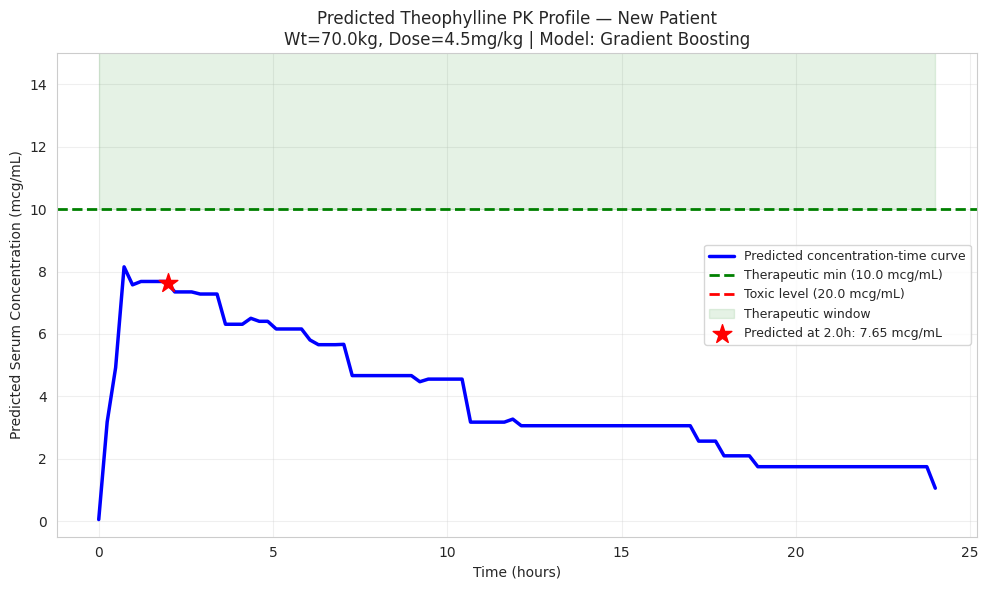


Model used: Gradient Boosting
Training R²: 0.628 (5-fold CV)
Test R²: 0.874
Test RMSE: 1.099 mcg/mL


In [17]:
# Block 8: Clinical prediction tool — predict concentration for a new patient

print("="*55)
print("CLINICAL PREDICTION TOOL")
print("="*55)
print("Predict theophylline serum concentration for a new patient")
print("="*55)

new_patient = {
    'Wt': 70.0,
    'Dose': 4.5,
    'Time': 2.0
}

print(f"\nNew Patient Parameters:")
print(f"  Body Weight:     {new_patient['Wt']} kg")
print(f"  Dose (mg/kg):    {new_patient['Dose']} mg/kg")
print(f"  Sampling Time:   {new_patient['Time']} hours post-dose")

new_patient['dose_per_kg'] = new_patient['Dose'] / new_patient['Wt']
new_patient['log_time'] = np.log1p(new_patient['Time'])
new_patient['time_squared'] = new_patient['Time'] ** 2

new_patient_df = pd.DataFrame([new_patient])[feature_columns]

if best_model_name == 'Support Vector Regression':
    new_patient_scaled = scaler.transform(new_patient_df)
    predicted_conc = best_model.predict(new_patient_scaled)[0]
else:
    predicted_conc = best_model.predict(new_patient_df)[0]

print(f"\n{'='*55}")
print(f"PREDICTED SERUM CONCENTRATION: {predicted_conc:.2f} mcg/mL")
print(f"{'='*55}")

therapeutic_min = 10.0
therapeutic_max = 20.0
toxic_level = 20.0

if predicted_conc < therapeutic_min:
    status = "SUBTHERAPEUTIC"
    recommendation = "Concentration below therapeutic range. Consider dose increase."
    color_note = "(Below 10 mcg/mL — insufficient for bronchodilation)"
elif therapeutic_min <= predicted_conc <= therapeutic_max:
    status = "THERAPEUTIC"
    recommendation = "Concentration within therapeutic range. Current dose appropriate."
    color_note = "(Within 10-20 mcg/mL — safe and effective range)"
else:
    status = "POTENTIALLY TOXIC"
    recommendation = "Concentration above therapeutic range. Consider dose reduction immediately."
    color_note = "(Above 20 mcg/mL — risk of nausea, seizures, arrhythmias)"

print(f"Clinical Status: {status}")
print(f"Therapeutic Range: {therapeutic_min}-{therapeutic_max} mcg/mL")
print(f"Note: {color_note}")
print(f"Recommendation: {recommendation}")

time_points = np.linspace(0, 24, 100)
predicted_curve = []

for t in time_points:
    patient_t = {
        'Wt': new_patient['Wt'],
        'Dose': new_patient['Dose'],
        'Time': t,
        'dose_per_kg': new_patient['Dose'] / new_patient['Wt'],
        'log_time': np.log1p(t),
        'time_squared': t ** 2
    }
    patient_t_df = pd.DataFrame([patient_t])[feature_columns]

    if best_model_name == 'Support Vector Regression':
        patient_t_scaled = scaler.transform(patient_t_df)
        conc_t = best_model.predict(patient_t_scaled)[0]
    else:
        conc_t = best_model.predict(patient_t_df)[0]

    predicted_curve.append(max(0, conc_t))

plt.figure(figsize=(10, 6))
plt.plot(time_points, predicted_curve, 'b-',
         linewidth=2.5, label='Predicted concentration-time curve')
plt.axhline(y=therapeutic_min, color='green', linestyle='--',
            linewidth=2, label=f'Therapeutic min ({therapeutic_min} mcg/mL)')
plt.axhline(y=therapeutic_max, color='red', linestyle='--',
            linewidth=2, label=f'Toxic level ({therapeutic_max} mcg/mL)')
plt.fill_between(time_points, therapeutic_min, therapeutic_max,
                  alpha=0.1, color='green',
                  label='Therapeutic window')
plt.scatter([new_patient['Time']], [predicted_conc],
            color='red', s=200, zorder=5,
            label=f'Predicted at {new_patient["Time"]}h: {predicted_conc:.2f} mcg/mL',
            marker='*')
plt.xlabel('Time (hours)')
plt.ylabel('Predicted Serum Concentration (mcg/mL)')
plt.title(
    f'Predicted Theophylline PK Profile — New Patient\n'
    f'Wt={new_patient["Wt"]}kg, Dose={new_patient["Dose"]}mg/kg | '
    f'Model: {best_model_name}'
)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, 15)
plt.tight_layout()
plt.show()

print(f"\nModel used: {best_model_name}")
print(f"Training R²: {results[best_model_name]['cv_mean']:.3f} "
      f"(5-fold CV)")
print(f"Test R²: {results[best_model_name]['r2']:.3f}")
print(f"Test RMSE: {results[best_model_name]['rmse']:.3f} mcg/mL")

Meaning of Block 8:

Purpose: Demonstrate the real-world clinical utility of the trained model by predicting theophylline serum concentration for a hypothetical new patient — exactly how a clinical decision support tool would work in a hospital pharmacy or clinical pharmacology setting.

What data comes IN: best_model, scaler, feature_columns from previous blocks. A new patient's clinical parameters entered as a dictionary.

What the new patient represents: A 70 kg adult patient receiving theophylline at 4.5 mg/kg, with a blood sample taken 2 hours after dose administration. These are realistic, typical values for theophylline dosing in a clinical setting.

What happens inside — line by line:

new_patient = {'Wt': 70.0, 'Dose': 4.5, 'Time': 2.0} — defines the three raw clinical inputs a pharmacokineticist would have for a new patient. Students can change these values to explore "what if" scenarios — what happens to predicted concentration if the dose is increased? What if the patient is lighter? What if the blood sample is taken later?
Feature engineering for new patient: the same three transformations applied in Block 3 (dose_per_kg, log_time, time_squared) must be applied identically to any new patient. This is a critical real-world modeling concept — features used at prediction time must exactly match features used at training time.
new_patient_df = pd.DataFrame([new_patient])[feature_columns] — formats the patient data into a DataFrame with exactly the same column order as training data. Column order matters for ML models — wrong order would produce wrong predictions.
scaler.transform(new_patient_df) — applies the same scaling learned from training data to the new patient's features. The scaler uses means and standard deviations computed from the training set (Block 4) — not from this new patient's values. This is correct practice: always use the training set scaler on new data.
Clinical interpretation block — checks the predicted concentration against the therapeutic range and generates an automatic clinical recommendation. This mirrors real clinical decision support systems used in hospital pharmacy practice.
time_points = np.linspace(0, 24, 100) — generates 100 evenly-spaced time points from 0 to 24 hours. For each time point, the model predicts concentration — building a complete 24-hour pharmacokinetic profile for this patient.
max(0, conc_t) — ensures predicted concentrations are never negative (a physical impossibility — drug concentration cannot be below zero). Machine learning models don't inherently know physical constraints, so we enforce this boundary manually.
The final plot shows the complete predicted 24-hour concentration-time curve with the therapeutic window highlighted in green — immediately showing when during the 24-hour period the patient is expected to be within the therapeutic range. The red star marks the specific time point and predicted concentration for the "blood sample at 2 hours" scenario.

What comes OUT: A predicted concentration value with clinical interpretation, a complete 24-hour predicted PK profile plot, and model performance summary — together forming a complete clinical pharmacokinetic prediction report.

Clinical significance: This block is the most practically important of the entire practical. In real hospital settings, clinical pharmacokinetic software (Bayesian dosing software) uses exactly this type of approach — fit a model to population data, then use it to predict individual patient concentrations and guide dosing decisions. Students completing this practical have built a simplified version of such a system.

MODEL INSIGHTS AND FEATURE IMPORTANCE


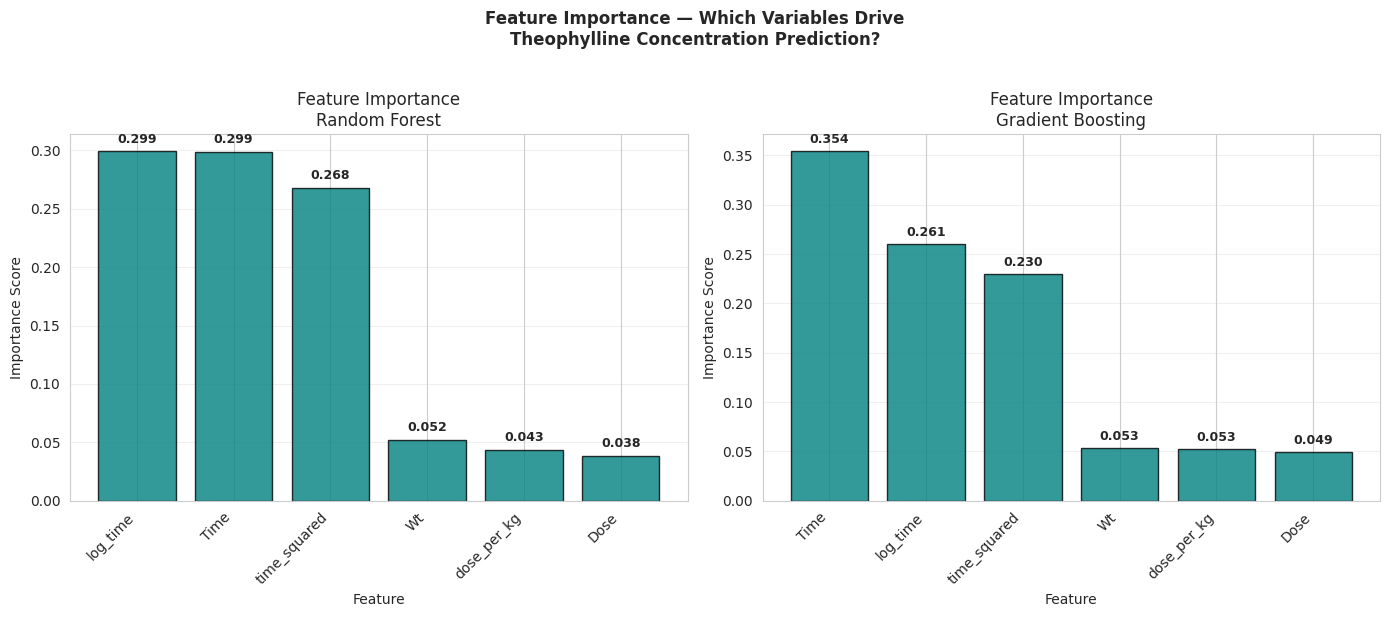


Pharmacological interpretation of feature importance:

HIGH importance for Time/log_time/time_squared:
  Time is the dominant driver of serum concentration.
  Drug concentration changes continuously with time
  (absorption 0-2h, distribution 2-4h, elimination 4-24h).

MODERATE importance for Dose/dose_per_kg:
  Higher dose → higher peak concentration (Cmax).
  Dose determines the total amount of drug available.

LOWER importance for Weight (Wt):
  Weight influences distribution volume and clearance,
  but since dose is already weight-normalized (mg/kg),
  direct weight effect is partially accounted for.


In [18]:
# Block 9: Feature importance and model insights

print("="*55)
print("MODEL INSIGHTS AND FEATURE IMPORTANCE")
print("="*55)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model_name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = results[model_name]['model']
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    bars = ax.bar(range(len(feature_columns)),
                   importances[indices],
                   color='teal', edgecolor='black', alpha=0.8)

    ax.set_xticks(range(len(feature_columns)))
    ax.set_xticklabels([feature_columns[i] for i in indices],
                        rotation=45, ha='right')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Importance Score')
    ax.set_title(f'Feature Importance\n{model_name}')
    ax.grid(True, alpha=0.3, axis='y')

    for bar, imp in zip(bars, importances[indices]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{imp:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.suptitle(
    'Feature Importance — Which Variables Drive\nTheophylline Concentration Prediction?',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print("\nPharmacological interpretation of feature importance:")
print()
print("HIGH importance for Time/log_time/time_squared:")
print("  Time is the dominant driver of serum concentration.")
print("  Drug concentration changes continuously with time")
print("  (absorption 0-2h, distribution 2-4h, elimination 4-24h).")
print()
print("MODERATE importance for Dose/dose_per_kg:")
print("  Higher dose → higher peak concentration (Cmax).")
print("  Dose determines the total amount of drug available.")
print()
print("LOWER importance for Weight (Wt):")
print("  Weight influences distribution volume and clearance,")
print("  but since dose is already weight-normalized (mg/kg),")
print("  direct weight effect is partially accounted for.")

Meaning of Block 9:

Purpose: Extract and visualize feature importance from the two tree-based models to understand WHICH clinical variables are most influential in predicting theophylline serum concentration — providing pharmacological insight beyond just prediction accuracy.

What data comes IN: results dictionary — specifically the trained Random Forest and Gradient Boosting models which have feature_importances_ attributes.

Why SVR is excluded from this plot: SVR does not provide feature importance scores — it is a "black box" model in this respect. Feature importance is a unique advantage of tree-based models (Random Forest, Gradient Boosting) where each split in each tree can be attributed to a specific feature. This is another dimension of the interpretability vs accuracy trade-off — the same concept taught in Practical 2's MLR vs Random Forest comparison.

What happens inside — line by line:

model.feature_importances_ — a built-in attribute of scikit-learn's tree-based models. It returns an array of scores (summing to 1.0) showing how much each feature contributed to reducing prediction error across all trees.
np.argsort(importances)[::-1] — sorts features from most to least important for display.
The pharmacological interpretation printed at the bottom connects the mathematical feature importance scores back to real pharmacokinetic science — this is the crucial bridge between ML output and clinical understanding that students need.

Expected findings and their clinical meaning:

Time and its transforms (log_time, time_squared) will dominate — because theophylline concentration changes dramatically from 0 to 24 hours (from 0 at time=0 to peak ~10 mcg/mL at ~1-2h then declining). Time is the strongest predictor of where the concentration-time curve is at any moment.
Dose will be moderately important — higher dose means higher overall concentrations at all time points.
Weight will have lower importance — because the dose is already expressed as mg/kg (weight-normalized), the additional contribution of raw weight is smaller.

What comes OUT: Two feature importance bar charts (RF and GB) with pharmacological interpretation — connecting ML model insights back to real clinical pharmacokinetics understanding.

In [19]:
# Block 10: Save the best model and results

import joblib

best_model_obj = results[best_model_name]['model']
joblib.dump(best_model_obj, 'theophylline_pk_model.pkl')
joblib.dump(scaler, 'theophylline_scaler.pkl')

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test_RMSE': [results[n]['rmse'] for n in results],
    'Test_R2': [results[n]['r2'] for n in results],
    'CV_R2_Mean': [results[n]['cv_mean'] for n in results],
    'CV_R2_Std': [results[n]['cv_std'] for n in results]
})
results_df.to_excel('theophylline_model_results.xlsx', index=False)

from google.colab import files
files.download('theophylline_pk_model.pkl')
files.download('theophylline_scaler.pkl')
files.download('theophylline_model_results.xlsx')

print("="*55)
print("PRACTICAL COMPLETE — SUMMARY")
print("="*55)
print(f"Dataset: Theophylline pharmacokinetics")
print(f"Subjects: 12 patients, 132 observations")
print(f"Features: {feature_columns}")
print(f"Target: Serum concentration (mcg/mL)")
print()
print("Model Performance Summary:")
print(results_df.to_string(index=False))
print()
print(f"Best Model: {best_model_name}")
print(f"Best Test R²: {results[best_model_name]['r2']:.4f}")
print(f"Best Test RMSE: {results[best_model_name]['rmse']:.4f} mcg/mL")
print()
print("Files saved:")
print("1. theophylline_pk_model.pkl — Best trained model")
print("2. theophylline_scaler.pkl  — Feature scaler")
print("3. theophylline_model_results.xlsx — All model metrics")
print("="*55)
print()
print("CLINICAL SIGNIFICANCE:")
print("This model predicts theophylline serum concentration")
print("from patient weight, dose, and sampling time.")
print("Therapeutic range: 10-20 mcg/mL")
print("Use Block 8 to predict concentration for any new patient.")
print("="*55)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PRACTICAL COMPLETE — SUMMARY
Dataset: Theophylline pharmacokinetics
Subjects: 12 patients, 132 observations
Features: ['Wt', 'Dose', 'Time', 'dose_per_kg', 'log_time', 'time_squared']
Target: Serum concentration (mcg/mL)

Model Performance Summary:
                    Model  Test_RMSE  Test_R2  CV_R2_Mean  CV_R2_Std
            Random Forest   1.201890 0.848988    0.670609   0.150465
        Gradient Boosting   1.098905 0.873758    0.627881   0.155320
Support Vector Regression   1.777786 0.669599    0.640381   0.231088

Best Model: Gradient Boosting
Best Test R²: 0.8738
Best Test RMSE: 1.0989 mcg/mL

Files saved:
1. theophylline_pk_model.pkl — Best trained model
2. theophylline_scaler.pkl  — Feature scaler
3. theophylline_model_results.xlsx — All model metrics

CLINICAL SIGNIFICANCE:
This model predicts theophylline serum concentration
from patient weight, dose, and sampling time.
Therapeutic range: 10-20 mcg/mL
Use Block 8 to predict concentration for any new patient.


Meaning of Block 10:

Purpose: Save all deliverables permanently — the trained best model, the feature scaler, and the model comparison results table — so they can be reused clinically without retraining.

What data comes IN: results dictionary, best_model_name, scaler, feature_columns from all previous blocks.

What happens inside — line by line:

joblib.dump(best_model_obj, 'theophylline_pk_model.pkl') — saves the best-performing trained model. This is the model that should be used for clinical prediction in Block 8 for any new patient.
joblib.dump(scaler, 'theophylline_scaler.pkl') — saves the feature scaler separately. This is critically important: when using the saved model to predict for new patients, the scaler MUST be loaded alongside the model. If SVR is the best model, all new patient data must be scaled with this exact scaler before prediction. If RF or GB is best, the scaler is saved but not needed for prediction — however saving it ensures consistency across all future use.
results_df.to_excel('theophylline_model_results.xlsx', index=False) — saves the model comparison table as Excel — a clean, shareable report of all three models' performance metrics that can be included directly in a lab report or research paper.
The CLINICAL SIGNIFICANCE section at the end explicitly connects what was built to real-world clinical pharmacology practice — reminding students (and instructors) that this is not just a coding exercise but a simplified version of the clinical pharmacokinetic decision support tools used in hospitals.

What comes OUT: Three files downloaded to desktop:

theophylline_pk_model.pkl — best trained regression model
theophylline_scaler.pkl — feature scaler (needed if SVR is best)
theophylline_model_results.xlsx — complete model comparison report